# Dollar Bar Dataset Builder

Downloads Binance Vision aggTrade ZIPs, converts them to dollar bars, engineers
microstructure features, and writes a Parquet file ready for ML prototyping.

**No database required.** ZIPs are cached locally in `data/zip_cache/` so
re-running the notebook is fast after the first download.

---
### Output columns
| Column | Description |
|---|---|
| `open/high/low/close` | OHLC prices |
| `volume`, `dollar_volume` | Total and dollar volume |
| `buy_volume`, `sell_volume` | Tick-rule classified volumes |
| `trade_count` | Trades per bar |
| `ofi` | Order Flow Imbalance ∈ [−1, 1] |
| `kyle_lambda` | Price impact per unit signed flow |
| `realized_vol` | √Σ(log return)² over bar trades |
| `duration_s` | Seconds to fill bar |
| `log_return` | log(close / prev_close) |
| `vpin_10`, `vpin_50` | Rolling VPIN over 10 / 50 bars |
| `dollar_vol_z` | Z-score of dollar_volume (rolling 50-bar window) |
| `ofi_lag1`, `ofi_lag2` | Lagged OFI |
| `kyle_lag1` | Lagged Kyle λ |
| `vol_lag1` | Lagged realized volatility |
| `ret_1b`, `ret_5b` | Forward log returns (target variables) |

In [1]:
# ── 0. Imports ──────────────────────────────────────────────────────────────
import sys
from pathlib import Path

ROOT = Path("__file__").resolve().parent.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import math
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import date, timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.ingestion.historical import stream_trades, iter_dates, fetch_zip
from src.processing.bars import AccumulatorState, process_trade
from src.processing.threshold import calibrate

sns.set_theme(style="darkgrid")
print("Imports OK")

Imports OK


In [2]:
# ── 1. Parameters ────────────────────────────────────────────────────────────
SYMBOL              = "BTCUSDT"
TARGET_BARS_PER_DAY = 75
CALIB_DAYS          = 5       # days sampled to estimate the threshold
DOWNLOAD_WORKERS    = 8       # parallel download threads

END_DATE   = date.today() - timedelta(days=3)
START_DATE = END_DATE - timedelta(days=89)   # 90 days

CACHE_DIR = ROOT / "data" / "zip_cache"      # ZIPs saved here; delete to force re-download
OUT_PATH  = ROOT / "data" / "dollar_bars.parquet"

print(f"Symbol : {SYMBOL}")
print(f"Range  : {START_DATE} → {END_DATE}  ({(END_DATE - START_DATE).days + 1} days)")
print(f"Cache  : {CACHE_DIR}")
print(f"Output : {OUT_PATH}")

Symbol : BTCUSDT
Range  : 2026-01-14 → 2026-04-13  (90 days)
Cache  : C:\Users\Atlas\Documents\Proyectos\quant_binance\data\zip_cache
Output : C:\Users\Atlas\Documents\Proyectos\quant_binance\data\dollar_bars.parquet


In [3]:
# ── 2. Parallel download ─────────────────────────────────────────────────────
# Download all missing ZIPs in parallel before doing any processing.
# Already-cached files are skipped immediately (fetch_zip checks disk first).

all_dates = list(iter_dates(START_DATE, END_DATE))

missing = [
    day for day in all_dates
    if not (CACHE_DIR / f"{SYMBOL}-aggTrades-{day.isoformat()}.zip").exists()
]
print(f"{len(all_dates) - len(missing)} days already cached, {len(missing)} to download")

if missing:
    failed = []
    with ThreadPoolExecutor(max_workers=DOWNLOAD_WORKERS) as pool:
        futures = {pool.submit(fetch_zip, SYMBOL, day, CACHE_DIR): day for day in missing}
        for i, future in enumerate(as_completed(futures), 1):
            day = futures[future]
            try:
                future.result()
            except Exception as exc:
                failed.append((day, exc))
            if i % 10 == 0 or i == len(missing):
                print(f"  downloaded {i}/{len(missing)}")

    if failed:
        print(f"WARNING: {len(failed)} days failed: {[d for d, _ in failed]}")

print("Download complete.")

0 days already cached, 90 to download
  downloaded 10/90
  downloaded 20/90
  downloaded 30/90
  downloaded 40/90
  downloaded 50/90
  downloaded 60/90
  downloaded 70/90
  downloaded 80/90
  downloaded 90/90
Download complete.


In [4]:
# ── 3. Threshold calibration ─────────────────────────────────────────────────
# Sample CALIB_DAYS evenly across the range — reads from cache, no network call.

step        = max(1, len(all_dates) // CALIB_DAYS)
sample_days = all_dates[::step][:CALIB_DAYS]

print(f"Calibrating on {len(sample_days)} sample days: {sample_days}")

daily_dvs = []
for day in sample_days:
    dv = sum(float(t["price"]) * float(t["qty"]) for t in stream_trades(SYMBOL, day, cache_dir=CACHE_DIR))
    daily_dvs.append(dv)
    print(f"  {day}  ${dv:>20,.0f}")

mean_daily_dv = float(np.mean(daily_dvs))
THRESHOLD     = calibrate(mean_daily_dv, TARGET_BARS_PER_DAY)

print(f"\nMean daily DV : ${mean_daily_dv:>20,.0f}")
print(f"Bar threshold : ${THRESHOLD:>20,.0f}")

Calibrating on 5 sample days: [datetime.date(2026, 1, 14), datetime.date(2026, 2, 1), datetime.date(2026, 2, 19), datetime.date(2026, 3, 9), datetime.date(2026, 3, 27)]
  2026-01-14  $       2,201,535,822
  2026-02-01  $       1,974,920,557
  2026-02-19  $         968,863,573
  2026-03-09  $       1,967,622,051
  2026-03-27  $       1,917,318,223

Mean daily DV : $       1,806,052,045
Bar threshold : $          24,080,694


In [5]:
# ── 4. Ingestion loop ────────────────────────────────────────────────────────
# Sequential by design: AccumulatorState is stateful across days.
# All reads come from disk cache — typically 1-2 min for 90 days.

state = AccumulatorState(symbol=SYMBOL, threshold=THRESHOLD)
bars  = []

for i, day in enumerate(all_dates):
    day_count = 0
    for trade in stream_trades(SYMBOL, day, cache_dir=CACHE_DIR):
        bar = process_trade(state, trade)
        if bar:
            bars.append(bar)
            day_count += 1

    if (i + 1) % 10 == 0 or i == len(all_dates) - 1:
        print(f"  day {i+1:>3}/{len(all_dates)}  {day}  bars today={day_count:>4}  total={len(bars):>6}")

print(f"\nTotal bars collected: {len(bars)}")

  day  10/90  2026-01-23  bars today=  52  total=   571
  day  20/90  2026-02-02  bars today= 135  total=  1382
  day  30/90  2026-02-12  bars today=  67  total=  2658
  day  40/90  2026-02-22  bars today=  23  total=  3149
  day  50/90  2026-03-04  bars today= 133  total=  3920
  day  60/90  2026-03-14  bars today=  39  total=  4626
  day  70/90  2026-03-24  bars today=  60  total=  5242
  day  80/90  2026-04-03  bars today=  32  total=  5748
  day  90/90  2026-04-13  bars today=  72  total=  6232

Total bars collected: 6232


In [7]:
df.iloc[881:]

,symbol,open_time,close_time,open,high,low,close,volume,dollar_volume,buy_volume,sell_volume,trade_count,ofi,kyle_lambda,realized_vol,duration_s
881,BTCUSDT,2026-01-29T17:01:35.926000+00:00,2026-01-29T17:06:09.224000+00:00,85468.00,85470.01,85080.59,85080.59,283.16305,2.416341e+07,112.16452,170.99853,8438,-0.207774,0.056770,0.000392,273.298
882,BTCUSDT,2026-01-29T17:06:09.224000+00:00,2026-01-29T17:16:56.385000+00:00,85080.58,85305.76,85070.93,85150.00,283.23209,2.412734e+07,149.39466,133.83743,12308,0.054927,0.087107,0.000791,647.161
883,BTCUSDT,2026-01-29T17:16:56.385000+00:00,2026-01-29T17:20:54.999000+00:00,85149.99,85600.00,85135.70,85600.00,282.07189,2.410911e+07,179.62194,102.44995,8314,0.273590,0.212698,0.002348,238.614
884,BTCUSDT,2026-01-29T17:20:55+00:00,2026-01-29T17:26:19.311000+00:00,85600.00,85638.30,85124.94,85126.00,281.95904,2.408579e+07,155.86830,126.09074,10478,0.105610,0.076961,0.001409,324.311
885,BTCUSDT,2026-01-29T17:26:19.353000+00:00,2026-01-29T17:35:04.665000+00:00,85126.01,85250.01,84966.93,85102.63,283.27804,2.410036e+07,138.17365,145.10439,12213,-0.024466,0.069593,0.000719,525.312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6227,BTCUSDT,2026-04-13T22:54:41.615000+00:00,2026-04-13T23:01:22.464000+00:00,74624.34,74746.61,74448.54,74503.60,322.68275,2.408624e+07,176.35798,146.32477,15395,0.093073,0.113531,0.000879,400.849
6228,BTCUSDT,2026-04-13T23:01:22.480000+00:00,2026-04-13T23:11:34.271000+00:00,74503.60,74900.00,74450.00,74630.00,322.59717,2.409180e+07,189.33674,133.26043,16676,0.173828,0.114167,0.001187,611.791
6229,BTCUSDT,2026-04-13T23:11:34.271000+00:00,2026-04-13T23:20:51.912000+00:00,74630.00,74750.10,74531.75,74750.10,322.78984,2.410082e+07,126.30044,196.48940,11905,-0.217445,0.110995,0.001225,557.641
6230,BTCUSDT,2026-04-13T23:20:51.912000+00:00,2026-04-13T23:29:21.326000+00:00,74750.10,74805.60,74606.85,74758.94,322.33627,2.408312e+07,165.00754,157.32873,15005,0.023822,0.107854,0.000916,509.414


In [8]:
# ── 5. Build DataFrame ───────────────────────────────────────────────────────
df = pd.DataFrame(bars)

df["open_time"]  = pd.to_datetime(df["open_time"],  utc=True, format="ISO8601")
df["close_time"] = pd.to_datetime(df["close_time"], utc=True, format="ISO8601")
df = df.sort_values("open_time").reset_index(drop=True)

df.info()
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6232 entries, 0 to 6231
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   symbol         6232 non-null   object             
 1   open_time      6232 non-null   datetime64[ns, UTC]
 2   close_time     6232 non-null   datetime64[ns, UTC]
 3   open           6232 non-null   float64            
 4   high           6232 non-null   float64            
 5   low            6232 non-null   float64            
 6   close          6232 non-null   float64            
 7   volume         6232 non-null   float64            
 8   dollar_volume  6232 non-null   float64            
 9   buy_volume     6232 non-null   float64            
 10  sell_volume    6232 non-null   float64            
 11  trade_count    6232 non-null   int64              
 12  ofi            6232 non-null   float64            
 13  kyle_lambda    6232 non-null   float64          

,symbol,open_time,close_time,open,high,low,close,volume,dollar_volume,buy_volume,sell_volume,trade_count,ofi,kyle_lambda,realized_vol,duration_s
0,BTCUSDT,2026-01-14 00:00:00.042000+00:00,2026-01-14 00:15:34.340000+00:00,95413.99,95647.91,95363.86,95587.00,252.19293,2.408106e+07,122.87936,129.31357,16989,-0.025513,0.047414,0.000623,934.298
1,BTCUSDT,2026-01-14 00:15:34.446000+00:00,2026-01-14 00:38:44.068000+00:00,95586.99,95619.53,95154.04,95319.99,252.92046,2.412818e+07,99.23554,153.68492,16148,-0.215283,0.073066,0.000498,1389.622
2,BTCUSDT,2026-01-14 00:38:44.068000+00:00,2026-01-14 01:06:27.239000+00:00,95319.99,95400.00,95150.00,95291.11,252.83970,2.408812e+07,114.03603,138.80367,15950,-0.097958,0.121122,0.000922,1663.171


In [9]:
# ── 6. Feature engineering ───────────────────────────────────────────────────

df["log_return"] = np.log(df["close"] / df["close"].shift(1))

imbalance = (df["buy_volume"] - df["sell_volume"]).abs() / (
    df["buy_volume"] + df["sell_volume"]
)
df["vpin_10"] = imbalance.rolling(10, min_periods=5).mean()
df["vpin_50"] = imbalance.rolling(50, min_periods=25).mean()

dv_roll = df["dollar_volume"].rolling(50, min_periods=10)
df["dollar_vol_z"] = (df["dollar_volume"] - dv_roll.mean()) / dv_roll.std()

for col, lags in [("ofi", [1, 2]), ("kyle_lambda", [1]), ("realized_vol", [1])]:
    for lag in lags:
        label = (
            f"ofi_lag{lag}" if col == "ofi"
            else f"kyle_lag{lag}" if col == "kyle_lambda"
            else f"vol_lag{lag}"
        )
        df[label] = df[col].shift(lag)

df["ret_1b"] = df["log_return"].shift(-1)
df["ret_5b"] = df["log_return"].rolling(5).sum().shift(-5)

new_cols = ["log_return", "vpin_10", "vpin_50", "dollar_vol_z",
            "ofi_lag1", "ofi_lag2", "kyle_lag1", "vol_lag1", "ret_1b", "ret_5b"]
print(df[new_cols].describe().T[["count", "mean", "std", "min", "max"]].to_string())

               count      mean       std       min       max
log_return    6231.0 -0.000040  0.003469 -0.015938  0.017086
vpin_10       6228.0  0.186560  0.070484  0.042326  0.589463
vpin_50       6208.0  0.186503  0.040741  0.094163  0.378204
dollar_vol_z  6223.0  0.003313  1.001429 -0.972298  6.922418
ofi_lag1      6231.0 -0.031198  0.238942 -0.922110  0.934545
ofi_lag2      6230.0 -0.031207  0.238961 -0.922110  0.934545
kyle_lag1     6231.0  0.152868  0.234041  0.001340  5.990710
vol_lag1      6231.0  0.001276  0.001093  0.000155  0.022231
ret_1b        6231.0 -0.000040  0.003469 -0.015938  0.017086
ret_5b        6227.0 -0.000197  0.007663 -0.029096  0.034227


In [10]:
# ── 7. Write Parquet ─────────────────────────────────────────────────────────
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(OUT_PATH, index=False, engine="pyarrow", compression="snappy")

size_mb = OUT_PATH.stat().st_size / 1_048_576
print(f"Saved {len(df):,} rows × {len(df.columns)} columns → {OUT_PATH}")
print(f"File size: {size_mb:.2f} MB")

Saved 6,232 rows × 26 columns → C:\Users\Atlas\Documents\Proyectos\quant_binance\data\dollar_bars.parquet
File size: 1.33 MB


In [11]:
# ── 8. Quick EDA ─────────────────────────────────────────────────────────────

print("=== Null counts ===")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0].to_string() or "No nulls")
print()

=== Null counts ===
log_return       1
vpin_10          4
vpin_50         24
dollar_vol_z     9
ofi_lag1         1
ofi_lag2         2
kyle_lag1        1
vol_lag1         1
ret_1b           1
ret_5b           5



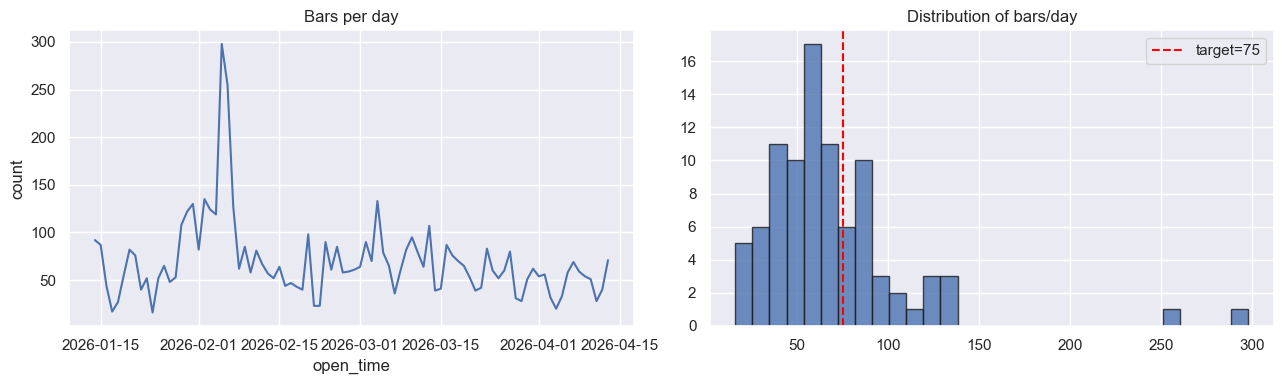

count     90.000000
mean      69.244444
std       41.707734
min       16.000000
25%       47.250000
50%       60.500000
75%       82.000000
max      298.000000


In [12]:
bars_per_day = df.groupby(df["open_time"].dt.date).size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bars_per_day.plot(ax=axes[0], title="Bars per day", ylabel="count")
axes[1].hist(bars_per_day, bins=30, edgecolor="k", alpha=0.8)
axes[1].axvline(TARGET_BARS_PER_DAY, color="red", linestyle="--", label=f"target={TARGET_BARS_PER_DAY}")
axes[1].set_title("Distribution of bars/day")
axes[1].legend()
plt.tight_layout()
plt.show()

print(bars_per_day.describe().to_string())

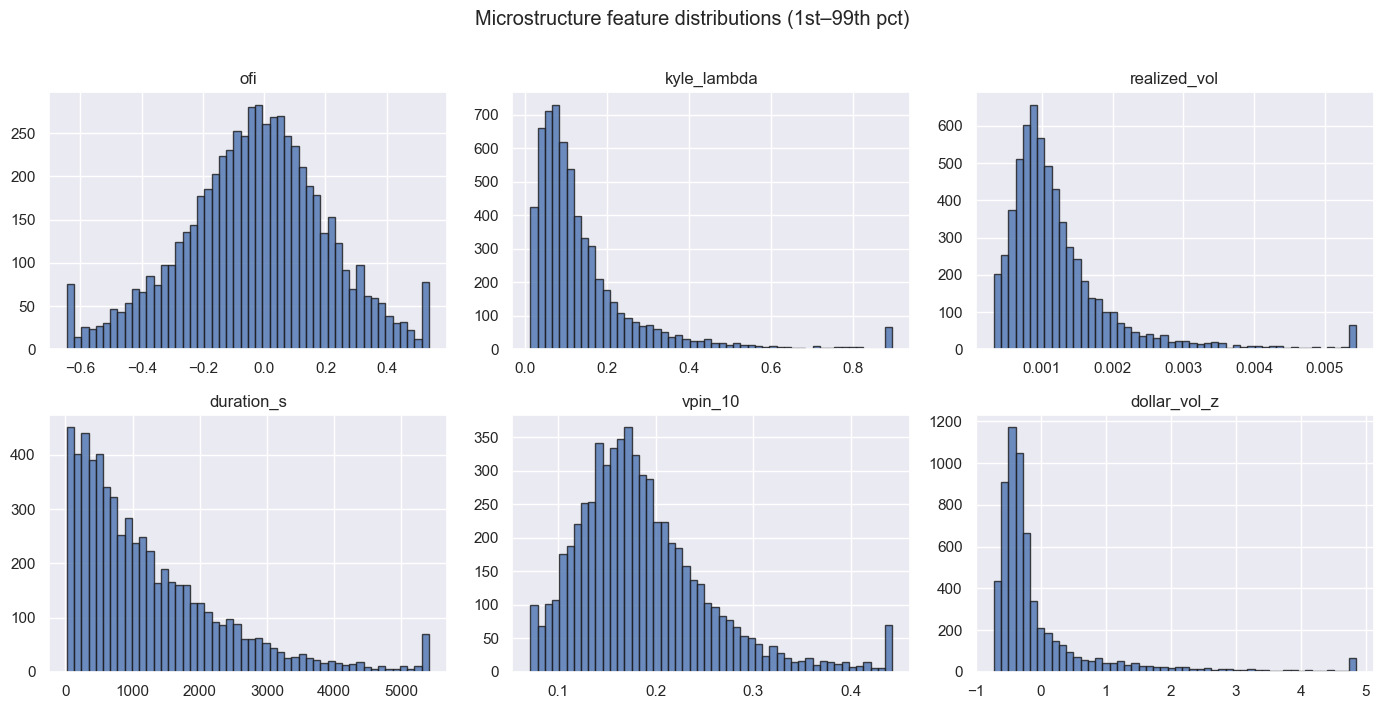

In [13]:
feat_cols = ["ofi", "kyle_lambda", "realized_vol", "duration_s", "vpin_10", "dollar_vol_z"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, feat_cols):
    data = df[col].dropna()
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    data.clip(lo, hi).hist(bins=50, ax=ax, edgecolor="k", alpha=0.8)
    ax.set_title(col)
plt.suptitle("Microstructure feature distributions (1st–99th pct)", y=1.01)
plt.tight_layout()
plt.show()

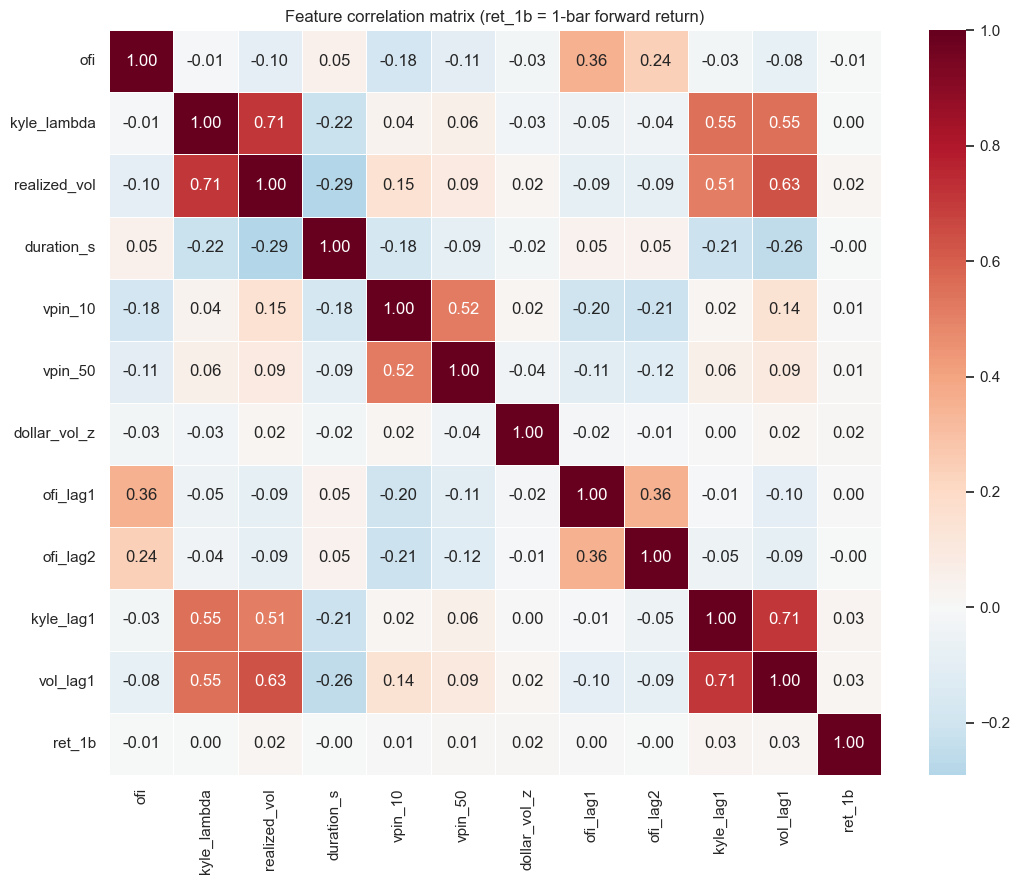

In [14]:
corr_cols = ["ofi", "kyle_lambda", "realized_vol", "duration_s",
             "vpin_10", "vpin_50", "dollar_vol_z",
             "ofi_lag1", "ofi_lag2", "kyle_lag1", "vol_lag1", "ret_1b"]

corr = df[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", center=0, cmap="RdBu_r", linewidths=0.4, ax=ax)
ax.set_title("Feature correlation matrix (ret_1b = 1-bar forward return)")
plt.tight_layout()
plt.show()

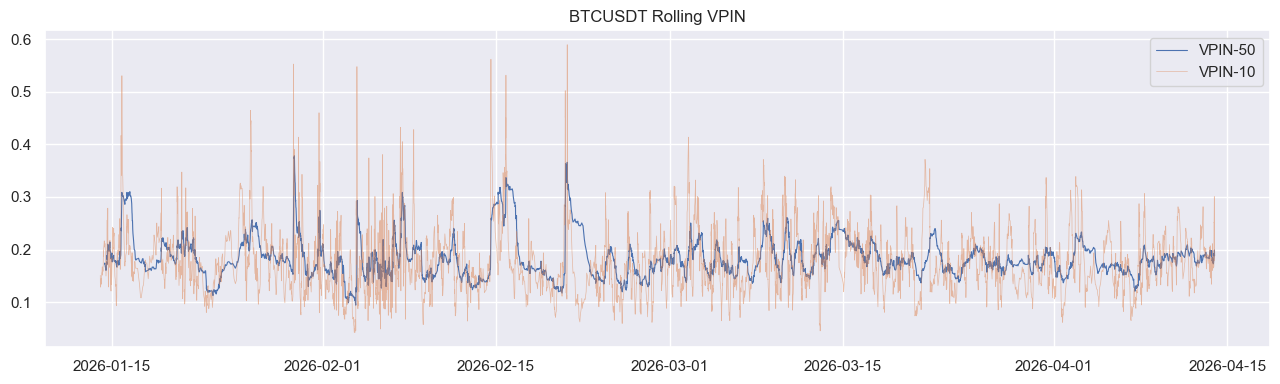

In [15]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df["open_time"], df["vpin_50"], lw=0.8, label="VPIN-50")
ax.plot(df["open_time"], df["vpin_10"], lw=0.5, alpha=0.5, label="VPIN-10")
ax.set_title(f"{SYMBOL} Rolling VPIN")
ax.legend()
plt.tight_layout()
plt.show()